# Imports

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import os
import warnings
warnings.filterwarnings('ignore')

# Loading Dataset

In [ ]:
df = pd.read_csv(r'C:\Users\PC\OneDrive\Desktop\ocr-proj\data\raw\A_Z Handwritten Data.csv')

In [ ]:
df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 372450 entries, 0 to 372449
Columns: 785 entries, 0 to 0.648
dtypes: int64(785)
memory usage: 2.2 GB


In [ ]:
df.describe()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
count,372450.000000,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,372450.0,...,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000,372450.000000
mean,13.523490,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.001616,0.001592,0.001117,0.000929,0.000685,0.000596,0.000618,0.000690,0.000239,0.000011
std,6.740824,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.490788,0.517297,0.421332,0.419180,0.385566,0.319820,0.208942,0.335227,0.134852,0.006554
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,10.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,14.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,18.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,25.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,252.000000,226.000000,229.000000,228.000000,235.000000,194.000000,103.000000,198.000000,82.000000,4.000000


# Data Cleaning

In [ ]:
df.isnull().sum()

0        0
0.1      0
0.2      0
0.3      0
0.4      0
        ..
0.644    0
0.645    0
0.646    0
0.647    0
0.648    0
Length: 785, dtype: int64

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.duplicated()

0         False
1         False
2         False
3         False
4         False
          ...  
372445     True
372446     True
372447     True
372448    False
372449     True
Length: 372450, dtype: bool

In [ ]:
df.drop_duplicates(inplace=True)    

In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
label_counts = df['0'].value_counts().sort_index()
print(label_counts)

0
0      7680
1      4804
2     12170
3      5430
4      6039
5      1147
6      3206
7      3974
8      1061
9      4593
10     3156
11     6226
12    10373
13     9909
14    29306
15    10087
16     3281
17     6170
18    24622
19    11698
20    14921
21     2616
22     5804
23     3557
24     5833
25     3432
Name: count, dtype: int64


In [ ]:
labels = df.iloc[:, 0]

label_counts = labels.value_counts().sort_index()

alphabet = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")


print("\n--- Exact Image Counts per Class ---")
for letter, count in zip(alphabet, label_counts.values):
    print(f"Letter {letter} (Label {alphabet.index(letter)}): {count:,} images")


--- Exact Image Counts per Class ---
Letter A (Label 0): 7,680 images
Letter B (Label 1): 4,804 images
Letter C (Label 2): 12,170 images
Letter D (Label 3): 5,430 images
Letter E (Label 4): 6,039 images
Letter F (Label 5): 1,147 images
Letter G (Label 6): 3,206 images
Letter H (Label 7): 3,974 images
Letter I (Label 8): 1,061 images
Letter J (Label 9): 4,593 images
Letter K (Label 10): 3,156 images
Letter L (Label 11): 6,226 images
Letter M (Label 12): 10,373 images
Letter N (Label 13): 9,909 images
Letter O (Label 14): 29,306 images
Letter P (Label 15): 10,087 images
Letter Q (Label 16): 3,281 images
Letter R (Label 17): 6,170 images
Letter S (Label 18): 24,622 images
Letter T (Label 19): 11,698 images
Letter U (Label 20): 14,921 images
Letter V (Label 21): 2,616 images
Letter W (Label 22): 5,804 images
Letter X (Label 23): 3,557 images
Letter Y (Label 24): 5,833 images
Letter Z (Label 25): 3,432 images


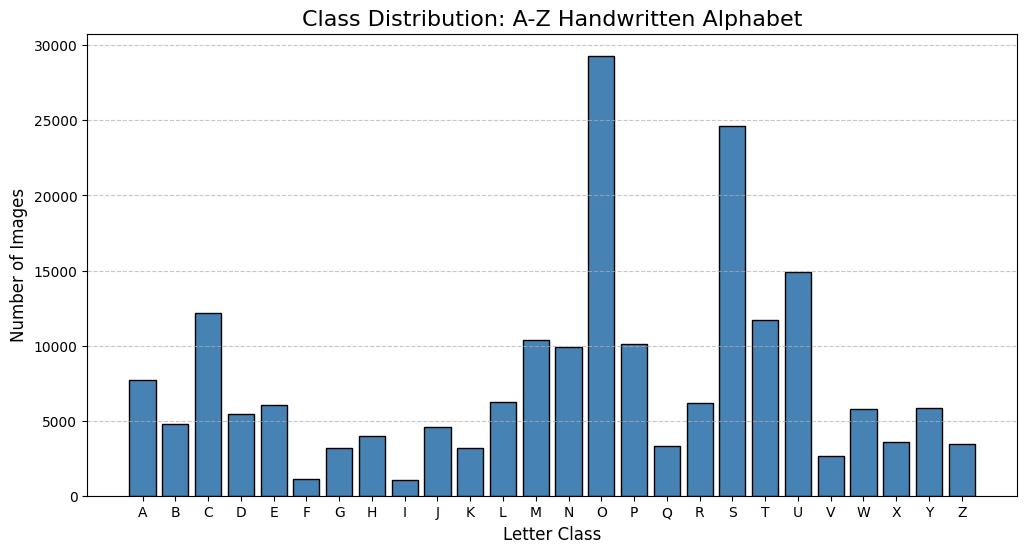

In [ ]:
#1. Class Distribution (plot 1)
plt.figure(figsize=(12, 6))
plt.bar(alphabet, label_counts.values, color='steelblue', edgecolor='black')
plt.title('Class Distribution: A-Z Handwritten Alphabet', fontsize=16)
plt.xlabel('Letter Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Preprocessing

In [ ]:
pixel_columns = df.columns[1:]
df[pixel_columns] = df[pixel_columns] / 255.0

df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df[pixel_columns] = df[pixel_columns].astype(np.float32)
df.head()

,0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,...,0.639,0.640,0.641,0.642,0.643,0.644,0.645,0.646,0.647,0.648
0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Train/Test Split

In [ ]:
X = df.drop(columns=['0']).values
y = df['0'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Label vector shape: {y.shape}")

Feature matrix shape: (201095, 784)
Label vector shape: (201095,)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_temp, X_test, y_temp, y_test = train_test_split( X, y, test_size=0.15, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=(0.15/0.85), stratify=y_temp, random_state=42)

In [ ]:
print(f"Training set shape: {X_train.shape}, {y_train.shape}")
print(f"Validation set shape: {X_val.shape}, {y_val.shape}")
print(f"Testing set shape: {X_test.shape}, {y_test.shape}")

Training set shape: (140765, 784), (140765,)
Validation set shape: (30165, 784), (30165,)
Testing set shape: (30165, 784), (30165,)


# Feature Engineering

In [ ]:
X_train_images = (X_train * 255).reshape(-1, 28, 28).astype(np.uint8)
X_val_images = (X_val * 255).reshape(-1, 28, 28).astype(np.uint8)
X_test_images = (X_test * 255).reshape(-1, 28, 28).astype(np.uint8)

print(f"Training images shape: {X_train_images.shape}")
print(f"Validation images shape: {X_val_images.shape}")
print(f"Testing images shape: {X_test_images.shape}")


Training images shape: (140765, 28, 28)
Validation images shape: (30165, 28, 28)
Testing images shape: (30165, 28, 28)


# Final Prep

### It is crucial to run the following 3 cells to convert the raw dataset(CSV) into processed data (training,validation & testing images)

In [ ]:
alphabet = list("ABCDEFGHIJKLMNOPQRSTUVWXYZ")

In [ ]:
def save_images_to_folders(images, labels, dataset_type):
    base_dir = f"data/processed/{dataset_type}"
    os.makedirs(base_dir, exist_ok=True)
    
    print(f"Saving {dataset_type} images...")
    for i in range(len(images)):
        img_array = images[i]
        letter = alphabet[labels[i]]
        
        class_dir = os.path.join(base_dir, letter)
        os.makedirs(class_dir, exist_ok=True)
        
        img = Image.fromarray(img_array)
        img.save(os.path.join(class_dir, f"{letter}_{i}.png"))

In [ ]:
save_images_to_folders(X_train_images, y_train, "train")
save_images_to_folders(X_val_images, y_val, "val")
save_images_to_folders(X_test_images, y_test, "test")

Saving train images...
Saving val images...
Saving test images...


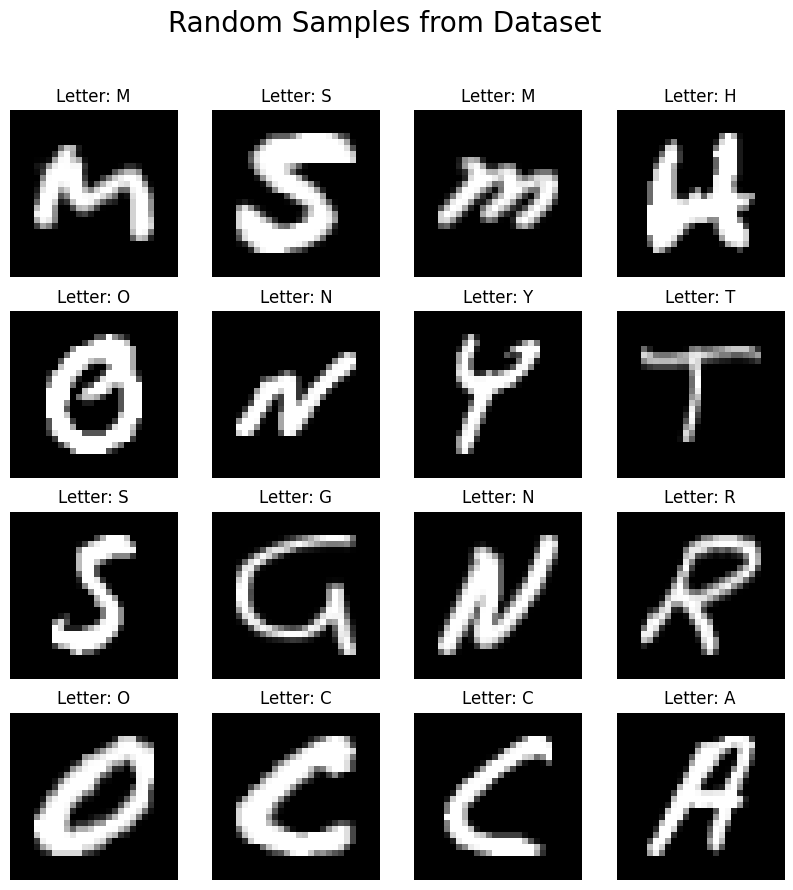

In [ ]:
# 2. Sample Grid (Plot 2)
plt.figure(figsize=(10,10))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(X_train_images[i], cmap='gray')
    plt.title(f"Letter: {alphabet[y_train[i]]}")
    plt.axis('off')
plt.suptitle("Random Samples from Dataset", fontsize=20)
plt.show()

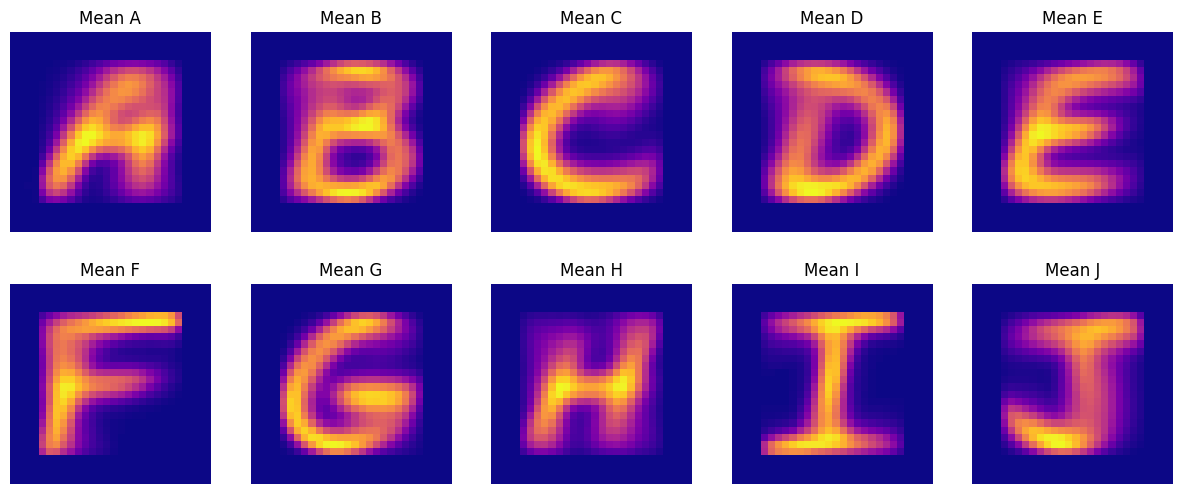

In [ ]:
# 3. Mean Images per Class (Plot 3)
plt.figure(figsize=(15, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    mean_img = X_train[y_train == i].mean(axis=0).reshape(28, 28)
    plt.imshow(mean_img, cmap='plasma')
    plt.title(f"Mean {alphabet[i]}")
    plt.axis('off')
plt.show()

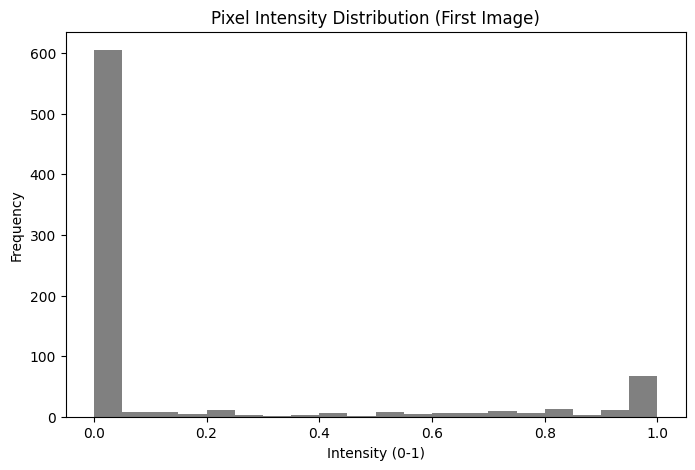

In [ ]:
# 4. Pixel Intensity Histogram (Plot 4)
plt.figure(figsize=(8, 5))
plt.hist(X_train[0], bins=20, color='gray')
plt.title("Pixel Intensity Distribution (First Image)")
plt.xlabel("Intensity (0-1)")
plt.ylabel("Frequency")
plt.show()

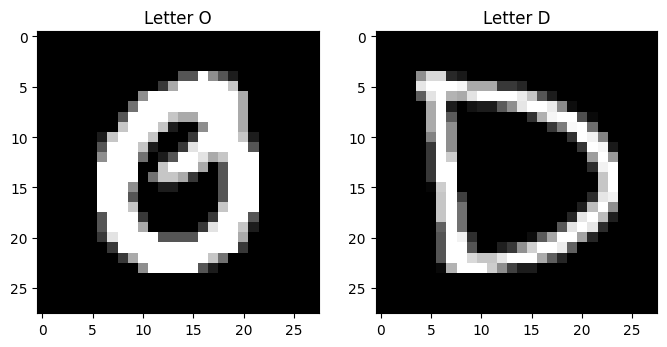

In [ ]:
# 5. Comparing O vs D  (Plot 5)
o_img = X_train[y_train == alphabet.index('O')][0].reshape(28,28)
d_img = X_train[y_train == alphabet.index('D')][0].reshape(28,28)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1); plt.imshow(o_img, cmap='gray'); plt.title("Letter O")
plt.subplot(1, 2, 2); plt.imshow(d_img, cmap='gray'); plt.title("Letter D")
plt.show()

# Data Augmentation & Visualizing Transforms

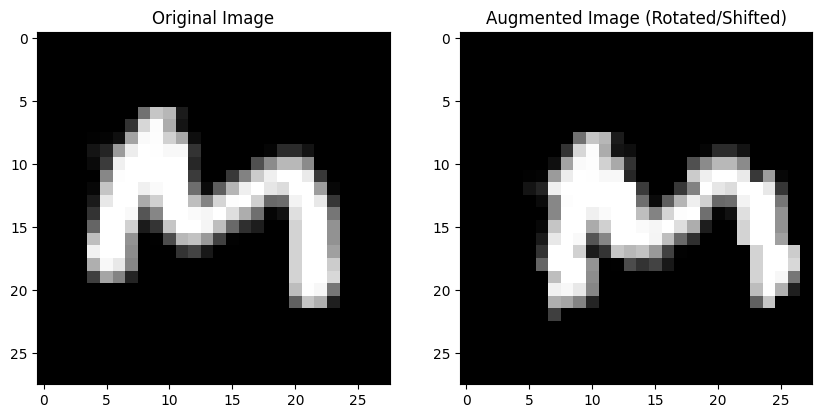

In [ ]:
from torchvision import transforms

# 1. Augmentation Pipeline
aug_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomRotation(degrees=15), 
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)), 
    transforms.ToTensor()
])

# 2. comparing before and after Agumetation (plot 6)
sample_img = X_train_images[0]
augmented_img = aug_transform(sample_img).squeeze().numpy()

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img, cmap='gray')
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(augmented_img, cmap='gray')
plt.title("Augmented Image (Rotated/Shifted)")
plt.show()

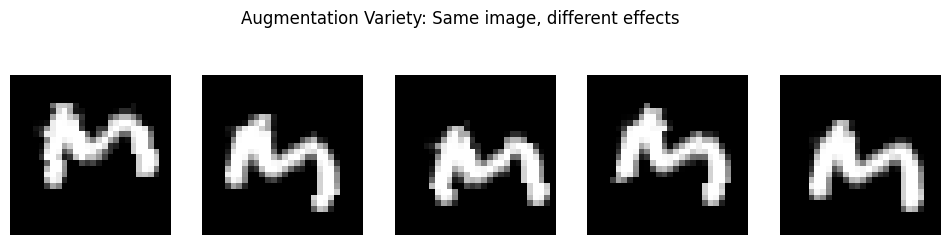

In [ ]:
#The Variety/Stochastic Plot (6)
plt.figure(figsize=(12, 3))
for i in range(5):
    plt.subplot(1, 5, i+1)
    aug_img = aug_transform(sample_img).squeeze().numpy()
    plt.imshow(aug_img, cmap='gray')
    plt.axis('off')
plt.suptitle("Augmentation Variety: Same image, different effects")
plt.show()